# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_Top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [4]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env("example.env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

DEEPSEEK_API_KEY=****daea
LANGSMITH_API_KEY=****0714
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials
Python 3.12.12 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                                                         
---------------------- | -------- | --------- | ------ | -----------------------------------------------------------------------------
langgraph              | >=1.0.0  | 1.0.6     | ✅ OK   | /home/zlzhangn/miniconda3/envs/langchain_learner/lib/python3.12/site-packages
langchain              | >=1.0.0  | 1.2.6     | ✅ OK   | /home/zlzhangn/miniconda3/envs/langchain_learner/lib/python3.12/site-packages
langchain-core         | >=1.0.0  | 1.2.7     | ✅ OK   | /home/zlzhangn/miniconda3/envs/langchain_learner/lib/python3.12/site-packages
langchain-openai       | >=1.0.0  | 1.1.7     | ✅ OK   | /home/zlzhangn/miniconda3/envs/langchain_learner/lib/python3.12/site-packages
langchain-anthropic    | >=1.0.0

In [5]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [6]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [7]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [8]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

Agent支持的模型 https://docs.langchain.com/oss/python/langchain/agents

In [9]:
from langchain.agents import create_agent

agent = create_agent(
    model="deepseek-chat",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext
)

Here's a display of the agent ReAct Loop.

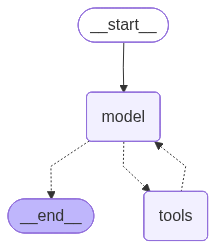

In [10]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [11]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================

I'll help you find which table has the largest number of entries. First, let me get a list of all tables in the database.
Tool Calls:
  execute_sql (call_00_n9btKEoxkyX59Zg0e8SFWPz0)
 Call ID: call_00_n9btKEoxkyX59Zg0e8SFWPz0
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

Now I'll count the number of entries in each table to find which one has the largest number of entries.
Tool Calls:
  execute_sql (call

In [12]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

I'll help you find which genre on average has the longest tracks. Let me start by exploring the database structure to understand what tables are available.
Tool Calls:
  execute_sql (call_00_xin3UnmUBU4tyTCrAe894rhb)
 Call ID: call_00_xin3UnmUBU4tyTCrAe894rhb
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

Good, I can see there are tables for `Genre` and `Track`. Let me examine the structure of these tabl

In [13]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================

I'll help you list all the tables in the database. Let me query the SQLite system tables to get this information.
Tool Calls:
  execute_sql (call_00_KO7XUGdCQrS1hMGB2AvNrl0O)
 Call ID: call_00_KO7XUGdCQrS1hMGB2AvNrl0O
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

Here are all the tables in the database:

1. **Album** - Likely contains information about music albums
2. **Artist** - Likely contains information about music 

**Create your own query here!**  Add some questions of your own.

In [ ]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

### Let's try this Studio